# EDA — DVF géolocalisées Paris
Demandes de Valeurs Foncières (transactions immobilières) · format parquet géolocalisé

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# ⚠️ Change le chemin si besoin
df = pd.read_parquet('../brute/Indicateurs de logement/dvf2.parquet')
df.columns = df.columns.str.strip()
print(f'Shape brute : {df.shape}')
df.head(3)

## 1. Vue générale

In [ ]:
print('Colonnes :')
print(df.columns.tolist())
print(f'\nLignes   : {len(df):,}')
print(f'Colonnes : {df.shape[1]}')
print(f'\nPériode  : {df["date_mutation"].min()} -> {df["date_mutation"].max()}')

Colonnes :
['id_mutation', 'date_mutation', 'nature_mutation', 'valeur_fonciere', 'code_postal', 'code_commune', 'nom_commune', 'code_departement', 'type_local', 'surface_reelle_bati', 'nombre_pieces_principales', 'longitude', 'latitude']

Lignes   : 420,058
Colonnes : 13

Période  : 2021-01-02 -> 2025-12-31


## 2. Typage des colonnes numériques

In [ ]:
for c in ['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales',
          'surface_terrain', 'longitude', 'latitude']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['date_mutation'] = pd.to_datetime(df['date_mutation'], errors='coerce')
df['annee'] = df['date_mutation'].dt.year
df.dtypes

id_mutation                             str
date_mutation                datetime64[us]
nature_mutation                         str
valeur_fonciere                     float64
code_postal                             str
code_commune                            str
nom_commune                             str
code_departement                        str
type_local                              str
surface_reelle_bati                 float64
nombre_pieces_principales           float64
longitude                           float64
latitude                            float64
annee                                 int32
dtype: object

## 3. Valeurs manquantes

Colonnes avec valeurs manquantes :
surface_reelle_bati          201520
valeur_fonciere                5048
nombre_pieces_principales      4192
type_local                     4137
code_postal                    1248
longitude                       695
latitude                        695
dtype: int64


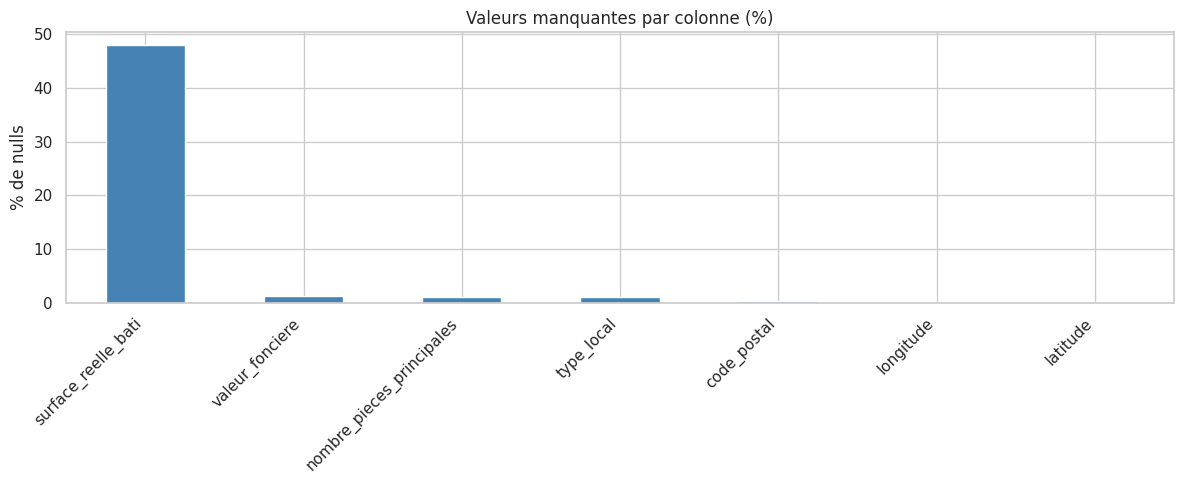

In [ ]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print('Colonnes avec valeurs manquantes :')
print(nulls)

ax = (nulls / len(df) * 100).plot(kind='bar', color='steelblue')
ax.set_title('Valeurs manquantes par colonne (%)')
ax.set_ylabel('% de nulls')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

La **surface** et le **nombre de pièces** sont souvent manquants : ce sont les lignes de type *Dépendance* (caves, parkings) et *Local industriel* qui n'ont pas de surface bâtie déclarée.

## 4. Doublons & structure des mutations
Une mutation (`id_mutation`) regroupe plusieurs lignes : un même acte de vente peut porter sur plusieurs lots/parcelles.

In [ ]:
doublons = df.duplicated().sum()
print(f'Doublons exacts        : {doublons}')
print(f'Lignes totales         : {len(df):,}')
print(f'id_mutation uniques    : {df["id_mutation"].nunique():,}')
print(f'Lignes par mutation    : {len(df) / df["id_mutation"].nunique():.2f} en moyenne')

Doublons exacts        : 80288
Lignes totales         : 420,058
id_mutation uniques    : 207,365
Lignes par mutation    : 2.03 en moyenne


## 5. Distribution par nature de mutation

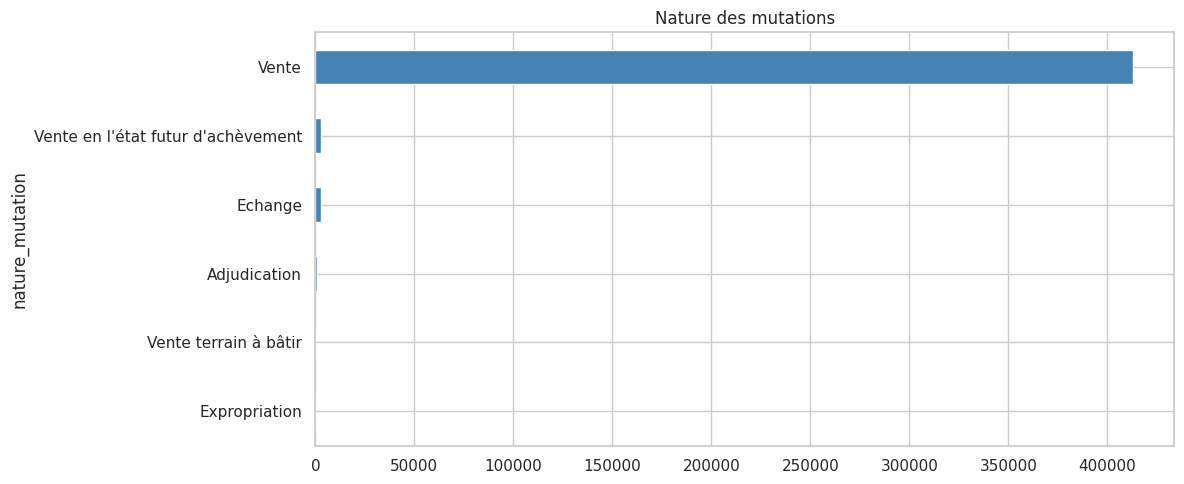

nature_mutation
Vente                                 413019
Vente en l'état futur d'achèvement      3046
Echange                                 3041
Adjudication                             898
Vente terrain à bâtir                     52
Expropriation                              2
Name: count, dtype: int64


In [ ]:
nat = df['nature_mutation'].value_counts()
ax = nat.plot(kind='barh', color='steelblue')
ax.set_title('Nature des mutations')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(nat)

## 6. Distribution par type de local

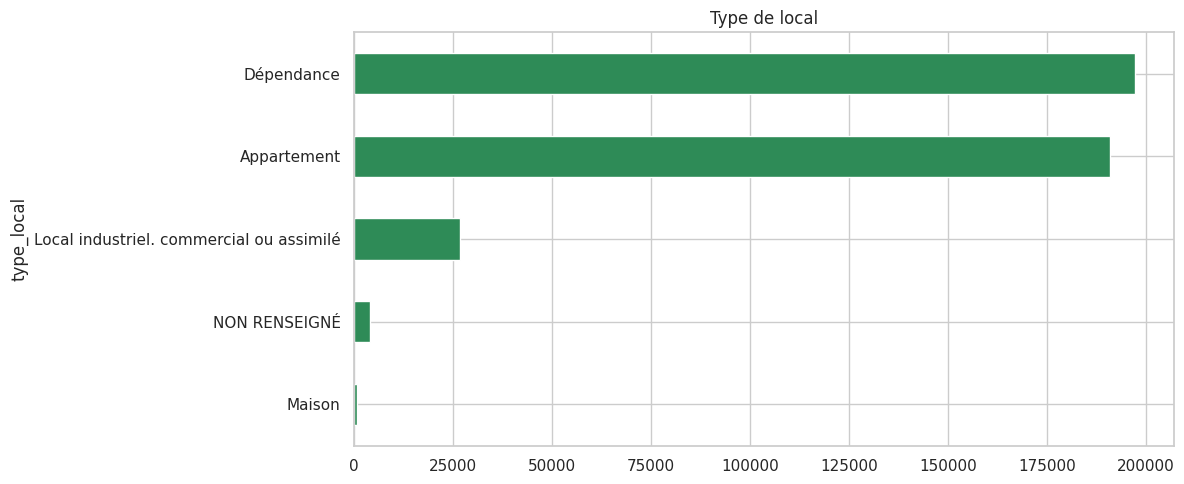

type_local
Dépendance                                  197245
Appartement                                 190904
Local industriel. commercial ou assimilé     26845
NON RENSEIGNÉ                                 4137
Maison                                         927
Name: count, dtype: int64


In [ ]:
tl = df['type_local'].fillna('NON RENSEIGNÉ').value_counts()
ax = tl.plot(kind='barh', color='seagreen')
ax.set_title('Type de local')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(tl)

## 7. Distribution par arrondissement
`code_commune` est au format '751XX' → on extrait le numéro d'arrondissement.

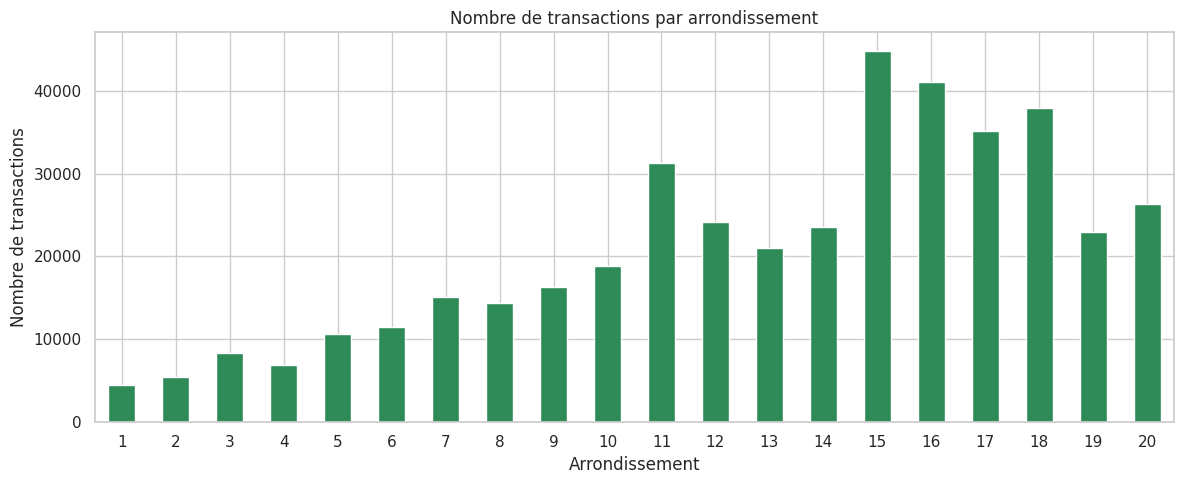

arrondissement
1      4487
2      5444
3      8379
4      6870
5     10674
6     11436
7     15079
8     14404
9     16270
10    18813
11    31237
12    24205
13    21029
14    23549
15    44798
16    41093
17    35083
18    37958
19    22979
20    26271
Name: count, dtype: int64


In [ ]:
df['arrondissement'] = df['code_commune'].astype(str).str[-2:].astype(int)

arr_counts = df['arrondissement'].value_counts().sort_index()
ax = arr_counts.plot(kind='bar', color='seagreen')
ax.set_title('Nombre de transactions par arrondissement')
ax.set_xlabel('Arrondissement')
ax.set_ylabel('Nombre de transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(arr_counts)

## 8. Filtrage métier : appartements vendus valides
Pour l'indicateur prix/m² : **appartements**, **ventes**, avec **valeur et surface > 0**.

In [ ]:
appt = df[(df['type_local'] == 'Appartement') &
          (df['nature_mutation'] == 'Vente') &
          (df['valeur_fonciere'] > 0) &
          (df['surface_reelle_bati'] > 0)].copy()

appt['prix_m2'] = appt['valeur_fonciere'] / appt['surface_reelle_bati']
print(f'Appartements vendus valides : {len(appt):,}')
pct_geo = appt[['longitude','latitude']].notna().all(axis=1).mean() * 100
print(f'Couverture GPS              : {pct_geo:.1f}%')

Appartements vendus valides : 186,577
Couverture GPS              : 99.8%


## 9. Distribution du prix au m² & outliers
Fourchette réaliste pour Paris : 2 000 – 40 000 €/m².

Outliers retirés : 25,727 -> 160,850 transactions


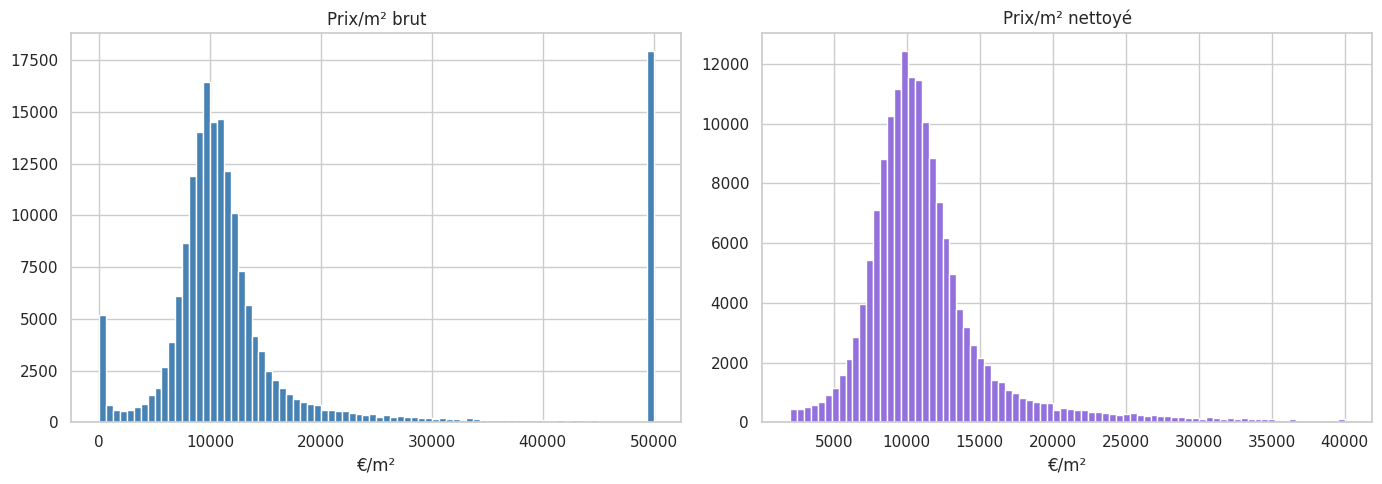

Médian : 10494 €/m² | Moyen : 11376 €/m²


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(appt['prix_m2'].clip(0, 50000), bins=80, color='steelblue')
axes[0].set_title('Prix/m² brut'); axes[0].set_xlabel('€/m²')

before = len(appt)
appt = appt[appt['prix_m2'].between(2000, 40000)]
print(f'Outliers retirés : {before - len(appt):,} -> {len(appt):,} transactions')

axes[1].hist(appt['prix_m2'], bins=80, color='mediumpurple')
axes[1].set_title('Prix/m² nettoyé'); axes[1].set_xlabel('€/m²')
plt.tight_layout()
plt.show()
print(f"Médian : {appt['prix_m2'].median():.0f} €/m² | Moyen : {appt['prix_m2'].mean():.0f} €/m²")

## 10. Prix médian au m² par arrondissement

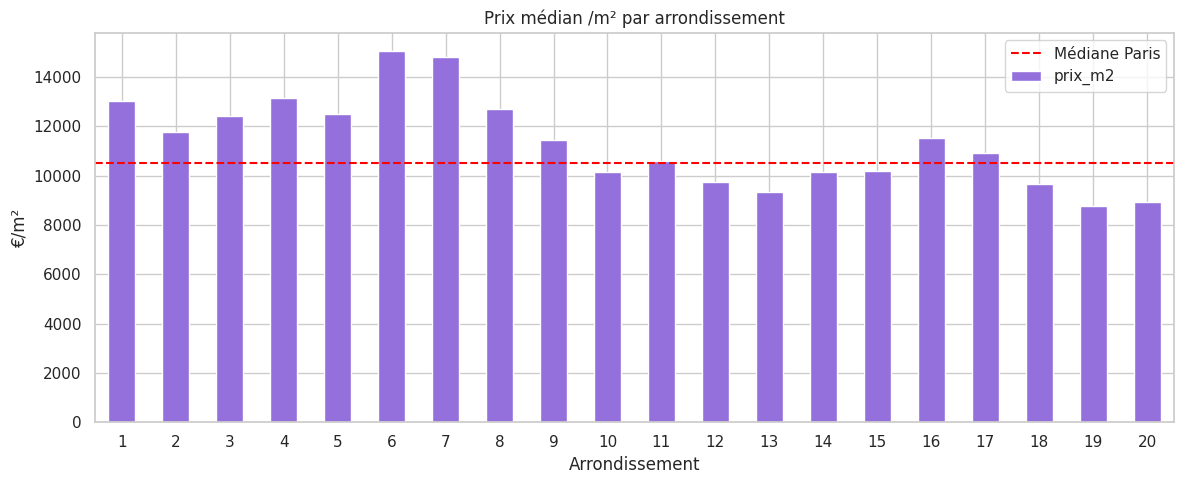

arrondissement
6     15040.0
7     14815.0
4     13158.0
1     13043.0
8     12718.0
5     12500.0
3     12400.0
2     11786.0
16    11521.0
9     11429.0
17    10908.0
11    10588.0
15    10192.0
10    10156.0
14    10143.0
12     9737.0
18     9643.0
13     9333.0
20     8947.0
19     8750.0
Name: prix_m2, dtype: float64


In [ ]:
prix_arr = appt.groupby('arrondissement')['prix_m2'].median().round(0)
ax = prix_arr.plot(kind='bar', color='mediumpurple')
ax.set_title('Prix médian /m² par arrondissement')
ax.set_xlabel('Arrondissement'); ax.set_ylabel('€/m²')
ax.axhline(appt['prix_m2'].median(), color='red', linestyle='--', label='Médiane Paris')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(prix_arr.sort_values(ascending=False))

## 11. Évolution temporelle du prix au m²

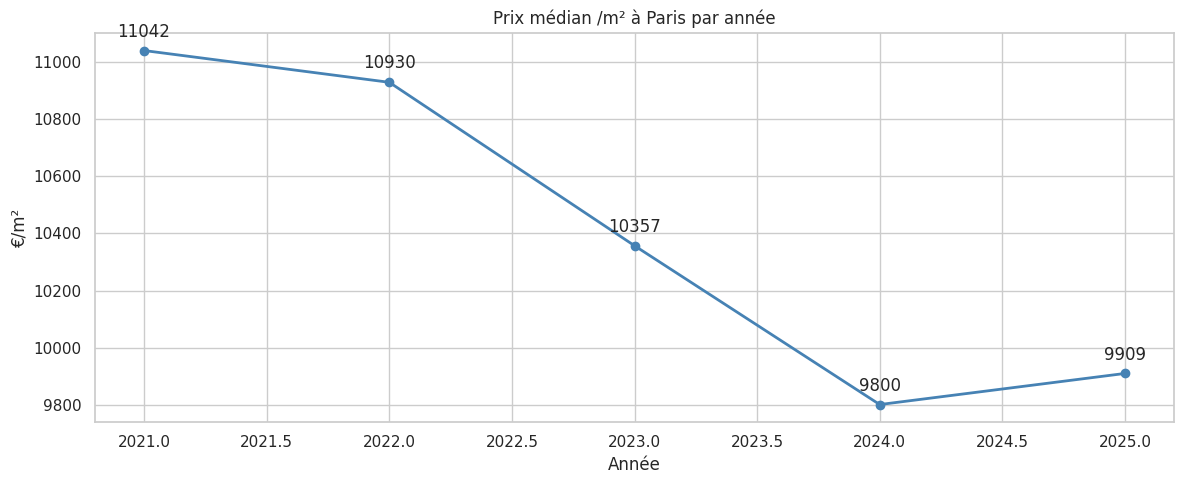

Évolution 2021 -> 2025 : -10.3%


In [ ]:
evo = appt.groupby('annee')['prix_m2'].median()
ax = evo.plot(marker='o', color='steelblue', linewidth=2)
ax.set_title('Prix médian /m² à Paris par année')
ax.set_xlabel('Année'); ax.set_ylabel('€/m²')
for x, y in zip(evo.index, evo.values):
    ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
plt.tight_layout()
plt.show()

if len(evo) > 1:
    ev = (evo.iloc[-1] - evo.iloc[0]) / evo.iloc[0] * 100
    print(f'Évolution {evo.index[0]} -> {evo.index[-1]} : {ev:+.1f}%')

## 12. Volume de ventes par année

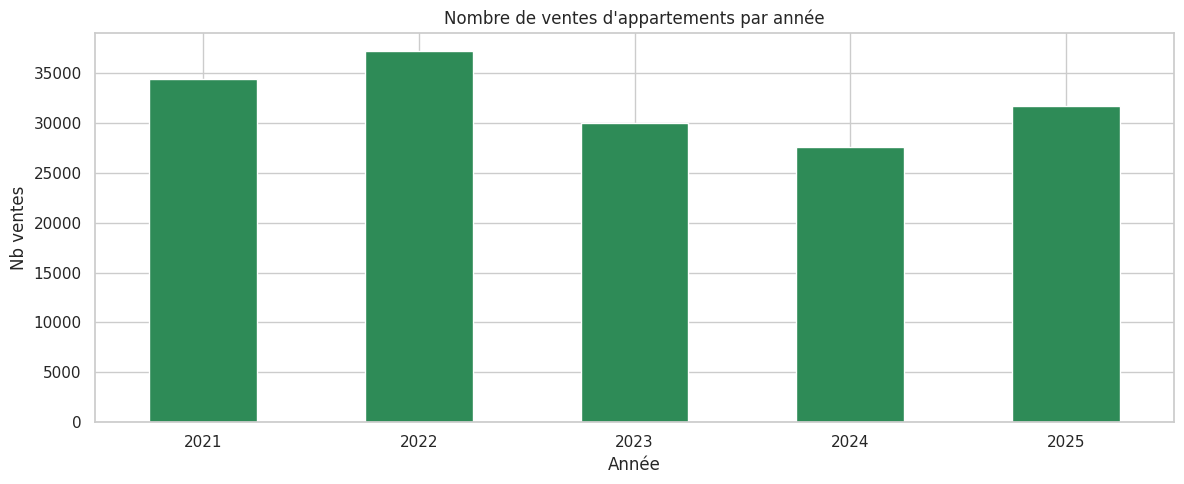

annee
2021    34394
2022    37157
2023    30027
2024    27590
2025    31682
dtype: int64


In [ ]:
vol = appt.groupby('annee').size()
ax = vol.plot(kind='bar', color='seagreen')
ax.set_title('Nombre de ventes d\'appartements par année')
ax.set_xlabel('Année'); ax.set_ylabel('Nb ventes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(vol)

## 13. Bornes géographiques (validation pour jointure quartier)

In [ ]:
print('Bornes géographiques des appartements :')
print(f"  Latitude  : {appt['latitude'].min():.4f} -> {appt['latitude'].max():.4f}")
print(f"  Longitude : {appt['longitude'].min():.4f} -> {appt['longitude'].max():.4f}")
print(f"  (Paris attendu : lat ~48.81-48.91, lon ~2.22-2.47)")

Bornes géographiques des appartements :
  Latitude  : 48.8188 -> 48.9006
  Longitude : 2.2559 -> 2.4128
  (Paris attendu : lat ~48.81-48.91, lon ~2.22-2.47)


## 14. Synthèse

In [ ]:
op_cher = prix_arr.idxmax(); op_abord = prix_arr.idxmin()
print('=== SYNTHÈSE EDA DVF GÉOLOCALISÉES ===')
print(f'Transactions totales       : {len(df):,}')
print(f'Mutations uniques          : {df["id_mutation"].nunique():,}')
print(f'Appartements vendus valides: {len(appt):,}')
print(f'Couverture GPS             : {pct_geo:.1f}%')
print(f'Arrondissements couverts   : {df["arrondissement"].nunique()}')
print(f'Période                    : {int(appt["annee"].min())} - {int(appt["annee"].max())}')
print(f'\nPrix médian Paris          : {appt["prix_m2"].median():.0f} €/m²')
print(f'Arrondissement + cher      : {op_cher}e ({prix_arr.max():.0f} €/m²)')
print(f'Arrondissement - cher      : {op_abord}e ({prix_arr.min():.0f} €/m²)')
print(f'\nPLAN SILVER :')
print('  1. Filtrer appartements / ventes / valeurs valides')
print('  2. Retirer outliers prix/m2 hors [2000, 40000]')
print('  3. Jointure spatiale point -> quartier (C_QU) via quartiers.csv')
print('  4. Agreger par quartier + arrondissement (prix median + evolution)')

=== SYNTHÈSE EDA DVF GÉOLOCALISÉES ===
Transactions totales       : 420,058
Mutations uniques          : 207,365
Appartements vendus valides: 160,850
Couverture GPS             : 99.8%
Arrondissements couverts   : 20
Période                    : 2021 - 2025

Prix médian Paris          : 10494 €/m²
Arrondissement + cher      : 6e (15040 €/m²)
Arrondissement - cher      : 19e (8750 €/m²)

PLAN SILVER :
  1. Filtrer appartements / ventes / valeurs valides
  2. Retirer outliers prix/m2 hors [2000, 40000]
  3. Jointure spatiale point -> quartier (C_QU) via quartiers.csv
  4. Agreger par quartier + arrondissement (prix median + evolution)
